In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:

def rho_bulge(x, y, z, rho0=99.5*1e9, r0=0.075, rcut=2.1):
    r       = np.sqrt(x**2 + y**2)
    r_prime = np.sqrt(r**2 + 4*z**2)
    return rho0 * np.exp(-(r_prime/rcut)**2) / (1 + (r_prime/r0)**1.8)


def rho_thin_disk(x, y, z, Sigma=816.6*1e9, r_s=2.90, z_s=0.3):
    R = np.sqrt(x**2 + y**2)
    return (Sigma / (2*z_s)) * np.exp(-R/r_s - np.abs(z)/z_s)


def rho_thick_disk(x, y, z, Sigma=209.5*1e9, r_s=3.31, z_s=0.9):
    
    
    R = np.sqrt(x**2 + y**2)
    return (Sigma / (2*z_s)) * np.exp(-R/r_s - np.abs(z)/z_s)  #Check if 2 is required


def stellar_rho_total(x, y, z):
    return rho_bulge(x, y, z) + rho_thin_disk(x, y, z) + rho_thick_disk(x, y, z)

In [7]:
def star_number(z,gal_R=8, small_R=1e-4):
    Z=np.linspace(-z, z, 10000)
    rho= stellar_rho_total(gal_R, 0, Z)
    small_R=1e-4
    Area=small_R**2 * np.pi
    mass = Area * np.trapezoid(rho, Z)

    print('Total mass in', small_R, 'kpc radius cylinder at R=8 kpc:', mass, 'kg')
    return(mass)

In [ ]:

def N_encounter_new(t,rho, v, b_max=0.1):
    return np.trapezoid(stellar_rho_total(xv[:,:3]) * xv[:,3:] * np.full_like(t,np.pi)  * np.full_like(t,b_max**2),t)

In [11]:
xv=np.array([  -6.492611  ,   0. ,          1.6569884 ,  21.354347 ,    0., -263.123    ])

In [8]:

def sample_cylinder(N, R, Z, seed=42):
    
    
    rng = np.random.default_rng(seed)

    # uniform in area: r = R * sqrt(u) ensures uniform area sampling
    r   = R * np.sqrt(rng.uniform(0, 1, N))
    phi = rng.uniform(0, 2*np.pi, N)
    z_array=np.linspace(-Z, Z, N)
    prob      = stellar_rho_total(0, 0, z_array)   # evaluate density along z axis (x=0, y=0)
    prob      = prob / prob.sum()    # normalise

    z = np.random.choice(z_array, size=N, p=prob)
    #z   = rng.uniform(-Z, Z, N)

    x = r * np.cos(phi)
    y = r * np.sin(phi)

    return x, y, z



Text(0, 0.5, 'z [kpc]')

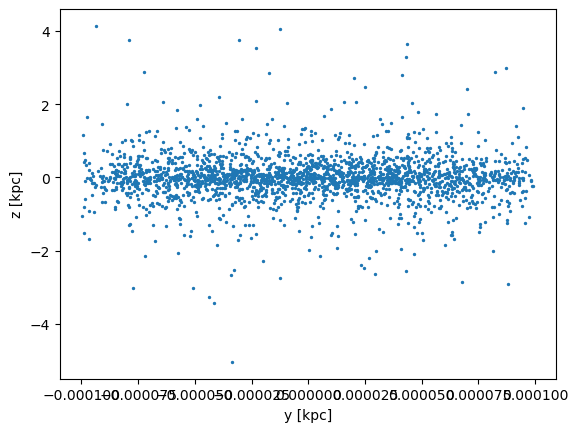

In [9]:
x,y,z=sample_cylinder(2212,1e-4,10,)
plt.scatter(y,z,s=2)
plt.xlabel('y [kpc]')
plt.ylabel('z [kpc]')

Text(0, 0.5, 'y [kpc]')

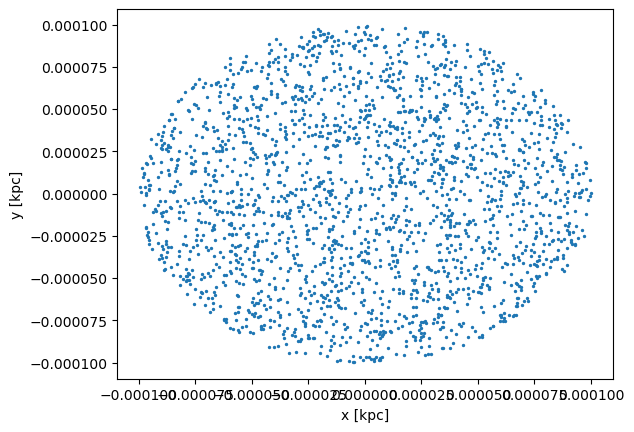

In [10]:
plt.scatter(x, y,s=2)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')